#### 모델링 : 함수 찾기
- 집의 평수를 알면 가격을 알 수있을까?
- Y = aX +b
- 데이터를 잘 설명하는 직선 하나를 찾는 것이 모델링
#### 손으로 숫자를 그린 이미지를 보고 숫자 7인지 맞출 수 있을까?
- 아주 복잡한 결정경계를 그린다. 경계를 그려주는 함수를 찾아내는 과정
##### ANN 인공신경망
- 단일층 : 신셩망이 하나 퍼셉트론 1x1 -> 뉴런
- 다층

외부의 자극이 들어와도 어떤 임계치 이상의 자극이 들어와야 감각이 인식이된다.
실제 신경반응과 유사

딥러닝에서
인공신경망이 구조라면, 활성화함수는 기능에 가깝다
구조만 있으면 선형 계산만 되고, 활성화 함수를 통해 비선형 패턴을 학습할 수 있음.

#### 활성화 함수...
- 계단 함수
- 시그모이드 Logisticfunction
    ```
    : 연속적인 값을 출력 - 미분이 가능 - 오차 역전파
    활성화 함수가 없다... f(z) = z
    y = (W100 x .... W1)X --> 거대한 1층짜리 선형모델
    초기 활성화 함수 스위치
    계단함수 if x > 0 1
            x <=   0
    주의 : 기울기 소실현상
    ```

#### 다층 신경망 MLP : 퍼셉트론을 여러개 쌓아서 올린구조
    - input layer : 데이터가 들어오는 곳(뉴런수 데이터의 특성 28X28 = 784)
    - hidden layer : 입력과 출력 사이에 있는 레이어
        # 이 숨겨진 레이어에서 양이 늘어났다 줄어들수도있다 줄었다가 늘어나서 간추릴 수도 있다.

In [31]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [32]:
# 파이토치로 딥러닝 샘플 만들어보기
# 파이토치 시작...!

# 필요 라이브러리
from sklearn.datasets import fetch_openml
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# X, y = fetch_openml('mnist_784',version=1,return_X_y=True,parser='Auto')

In [33]:
# MNIST  데이터셋 로드
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data()
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [34]:
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

4
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38
  190  25   0   0   0   0   0   0   0   0]
 [  0   0   0  13  25  10   0   0   0   0   0   0   0   0   0   0   0 112
  252 125   4   0   0   0   0   0   0   0]
 [  0   0   0 132 252 113   0   0   0   0   0   0   0   0   0   0   0  61
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 240  79   0   0   0   0   0   0   0   0   0   0  84
  252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 252 238  52   0   0   0   0   0   0   0 

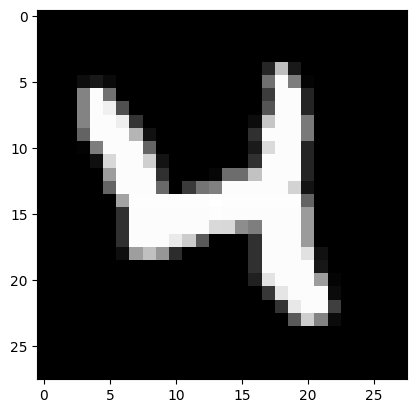

In [35]:
print(y_train[20])
plt.imshow(x_train[20],cmap='gray')
print(x_train[20])

In [36]:
# 데이터를 스케일링 : 표준화 :임의로 숫자를 정하여 나눠주기 :
    # 255로 나누기 -> 그 이유 : 0 ~ 255 이루어진 데이터 이기 때문에 255로 나누면 0~1사이의 값으로 스케일이 조정된다.
# 동일한 타입으로 연산하면 연산속도가 조금 더 빨라진다. 실수로 통일 ^ 실수로 통일한 이유? ^
x_train = x_train.astype(float) / 255.0
x_test = x_test.astype(float) / 255.0

In [37]:
# 데이터를 1차원형태로 넣어야 한다. -> keras의 기능 사용, keras.layers.Flatten() : only 데이터를 펴주는 기능

model = tf.keras.Sequential([
    # 1층 입력층 28 x 28  2D -> 784 ID
    tf.keras.layers.Flatten(input_shape=(28,28)),
    # 2층 은닉층
    tf.keras.layers.Dense(128,activation='relu'),  # ^
    # 출력층
    tf.keras.layers.Dense(10,activation='softmax') # softmax vs sigmoid ^
])
model.summary()

c:\김지은\파이썬_src\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
784*128+128

100480

In [39]:
128*10+10

1290

In [40]:
model.compile(
    optimizer = 'adam', # 빠르고 안정적인
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [41]:
model.fit(
    x_train,
    y_train,
    epochs = 5,
    validation_data = (x_test,y_test),
    verbose = 1 # 로그 출력
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9234 - loss: 0.2617 - val_accuracy: 0.9622 - val_loss: 0.1353
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9649 - loss: 0.1163 - val_accuracy: 0.9664 - val_loss: 0.1090
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9753 - loss: 0.0800 - val_accuracy: 0.9736 - val_loss: 0.0861
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9819 - loss: 0.0602 - val_accuracy: 0.9756 - val_loss: 0.0749
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9854 - loss: 0.0469 - val_accuracy: 0.9755 - val_loss: 0.0783


- 정답의 종류 클래스
#### 소프트 맥스 : 전체 클래스 중에서 하나 선택 - 정답이 1개인 경우
- 전체 합이 1
- 확률전체 클래스에 대해서, 0~1 다합치면 1되는 구조 0.2 0.6 0.2
#### 시그모이드 : 다중클래스 - 정답이 여러개인 경우
- 전체 합이 1이 아님
- 각 클래스에 대해서 확률을 0~1 사이로 변환 0.8 0.9 0.1

In [ ]:
pred = model.predict(x_test)
pred[0], y_test[0]
# 어설픈 딥러닝보단 제대로된 머신러닝이 더 나을 수 있다.
# 딥러닝을 사용하는 경우 : 복잡한 계산을 해야될대 사용한다. 영상, 이미지, 자연어 처리
                                # 레이어 기반의 그 구조를 효과를 받기 좋은 것들

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step


(array([2.2716382e-08, 1.0569055e-08, 9.4935185e-06, 6.2311906e-04,
        6.2891190e-12, 2.1888808e-07, 2.1227894e-12, 9.9933076e-01,
        1.2323728e-06, 3.5106641e-05], dtype=float32),
 np.uint8(7))

In [ ]:
model.score()

In [47]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9755 - loss: 0.0783


[0.07830191403627396, 0.9754999876022339]

In [50]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [ ]:
# classification_report으로 모델성능 조회해보기
# 필요한 매게변수 : y_pred, y_test
# y_pred 예측값을 무엇으로 넣어야될지에 대해서 :
    # 산출한 수치중에서 최댓값을 기준으로 점수를 비교한다. -> 값이 아닌 최댓값을 가지고있는 인덱스를 가져오기위해서 .argmax()를 사용한다.

from sklearn.metrics import classification_report
print(classification_report(y_test,np.argmax(pred, axis=1)))
# axis=0 → 세로 방향 (행을 따라 아래로)
# axis=1 → 가로 방향 (열을 따라 옆으로)
# 즉, 2차원 배열에서 axis=1을 지정하면 각 행(row)마다 연산을 수행

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.98      0.97      0.97      1010
           4       0.99      0.96      0.97       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.96      0.97      0.96       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
# 딥러닝의 경우에는 층을 어떻게 설계하냐에 따라서 바뀐다.
# 딥러닝에서 층이 깊어질수로 기울기가 날라가서나 폭발할수도있다. (은유적 표현)
# 그 층사이에 뭔가를 더 추가할수도 있다.